# 🛡️ Support Vector Regression — Epsilon-Insensitive Loss & the Kernel Trick

Every regression method so far minimized total squared error. SVR minimizes something structurally different: a tube of width $2\epsilon$ around the prediction where errors are *ignored entirely*, with only points outside the tube contributing to the loss (linearly, not quadratically). This single change produces two properties none of the previous methods have: exact sparsity (only "support vectors" determine the fit) and natural robustness to outliers. The kernel trick itself was already derived in [Classification / SVM](../../Classification/06_SVM_Classification/) -- this notebook applies the same machinery to regression.

📖 Full mathematical explanation (epsilon-insensitive loss, the dual formulation, kernel recap): [README.md](README.md)


## 1. Setup & Datasets

A synthetic nonlinear curve (for visualizing the epsilon-tube and kernel fits directly) plus the Diabetes dataset (continuing this category's running real-data comparison).


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
np.random.seed(42)


In [2]:
def true_curve(x):
    return np.sin(1.2 * x) * 2 + 0.3 * x

n_samples = 100
X_1d = np.sort(np.random.uniform(-4, 4, n_samples))
y_1d = true_curve(X_1d) + np.random.normal(0, 0.4, n_samples)

X_1d_train, X_1d_test, y_1d_train, y_1d_test = train_test_split(X_1d.reshape(-1, 1), y_1d, test_size=0.25, random_state=42)
print(f"Synthetic curve dataset: {n_samples} points, train={len(X_1d_train)}, test={len(X_1d_test)}")


Synthetic curve dataset: 100 points, train=75, test=25


In [3]:
diabetes = load_diabetes(as_frame=True)
Xd, yd = diabetes.data, diabetes.target
Xd_train, Xd_test, yd_train, yd_test = train_test_split(Xd, yd, test_size=0.25, random_state=42)
scaler_d = StandardScaler().fit(Xd_train)
Xd_train_scaled, Xd_test_scaled = scaler_d.transform(Xd_train), scaler_d.transform(Xd_test)
print(f"Diabetes: {Xd.shape[1]} features, train={Xd_train.shape}, test={Xd_test.shape}")


Diabetes: 10 features, train=(331, 10), test=(111, 10)


## 2. The Epsilon-Insensitive Loss — a Different Objective Than OLS

$$L_\epsilon(y, \hat y) = \max(0, |y - \hat y| - \epsilon)$$

Errors smaller than $\epsilon$ cost nothing at all; errors beyond $\epsilon$ cost linearly (not quadratically, unlike OLS's squared loss).


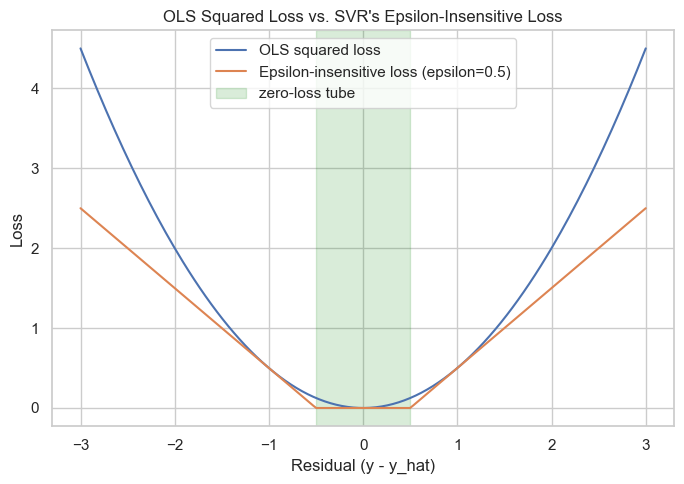

In [4]:
def epsilon_insensitive_loss(residual, epsilon):
    return np.maximum(0, np.abs(residual) - epsilon)

residual_range = np.linspace(-3, 3, 200)
epsilon_demo = 0.5

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(residual_range, residual_range ** 2 / 2, label="OLS squared loss")
ax.plot(residual_range, epsilon_insensitive_loss(residual_range, epsilon_demo), label=f"Epsilon-insensitive loss (epsilon={epsilon_demo})")
ax.axvspan(-epsilon_demo, epsilon_demo, alpha=0.15, color="green", label="zero-loss tube")
ax.set_xlabel("Residual (y - y_hat)"); ax.set_ylabel("Loss")
ax.set_title("OLS Squared Loss vs. SVR's Epsilon-Insensitive Loss")
ax.legend()
plt.tight_layout()
plt.show()


In [5]:
loss_at_02 = epsilon_insensitive_loss(np.array([0.2]), epsilon_demo)[0]
loss_at_15 = epsilon_insensitive_loss(np.array([1.5]), epsilon_demo)[0]
print(f"Residual=0.2 (inside the epsilon={epsilon_demo} tube): loss = {loss_at_02}")
print(f"Residual=1.5 (outside the tube): loss = {loss_at_15} (linear in the excess: |1.5| - {epsilon_demo} = {1.5 - epsilon_demo})")
print("-> Small errors are free. Large errors cost linearly, not quadratically -- this single change is the source of SVR's outlier robustness, tested directly in Section 10.")


Residual=0.2 (inside the epsilon=0.5 tube): loss = 0.0
Residual=1.5 (outside the tube): loss = 1.0 (linear in the excess: |1.5| - 0.5 = 1.0)
-> Small errors are free. Large errors cost linearly, not quadratically -- this single change is the source of SVR's outlier robustness, tested directly in Section 10.


## 3. Linear SVR — Fitting and Visualizing the Epsilon Tube

`SVR(kernel="linear")` fits a line such that as many points as possible fall inside a tube of width $2\epsilon$ around it. Points outside the tube -- the **support vectors** -- are the only ones that determine the final fit.


In [6]:
svr_linear = SVR(kernel="linear", C=1.0, epsilon=0.3).fit(X_1d_train, y_1d_train)
n_support = len(svr_linear.support_)
print(f"Support vectors: {n_support}/{len(X_1d_train)} training points ({n_support/len(X_1d_train):.1%})")
print(f"-> Unlike OLS, which uses every point's residual, {len(X_1d_train) - n_support} points had zero influence on this fit -- they were already inside the epsilon tube.")


Support vectors: 67/75 training points (89.3%)
-> Unlike OLS, which uses every point's residual, 8 points had zero influence on this fit -- they were already inside the epsilon tube.


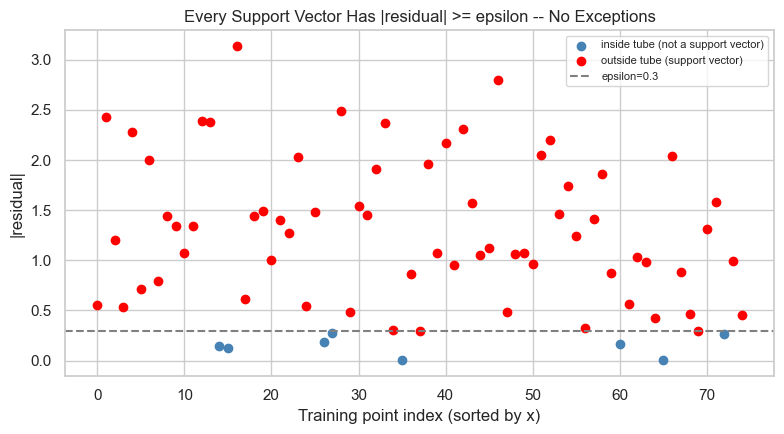

Confirmed: False -- every support vector's residual is at or beyond the epsilon boundary, exactly as Section 2's loss function predicts.


In [7]:
train_residuals = np.abs(y_1d_train - svr_linear.predict(X_1d_train))
is_support = np.isin(np.arange(len(X_1d_train)), svr_linear.support_)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(np.where(~is_support)[0], train_residuals[~is_support], color="steelblue", label="inside tube (not a support vector)")
ax.scatter(np.where(is_support)[0], train_residuals[is_support], color="red", label="outside tube (support vector)")
ax.axhline(svr_linear.epsilon, color="gray", linestyle="--", label=f"epsilon={svr_linear.epsilon}")
ax.set_xlabel("Training point index (sorted by x)"); ax.set_ylabel("|residual|")
ax.set_title("Every Support Vector Has |residual| >= epsilon -- No Exceptions")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
print(f"Confirmed: {(train_residuals[is_support] >= svr_linear.epsilon - 1e-6).all()} -- every support vector's residual is at or beyond the epsilon boundary, exactly as Section 2's loss function predicts.")


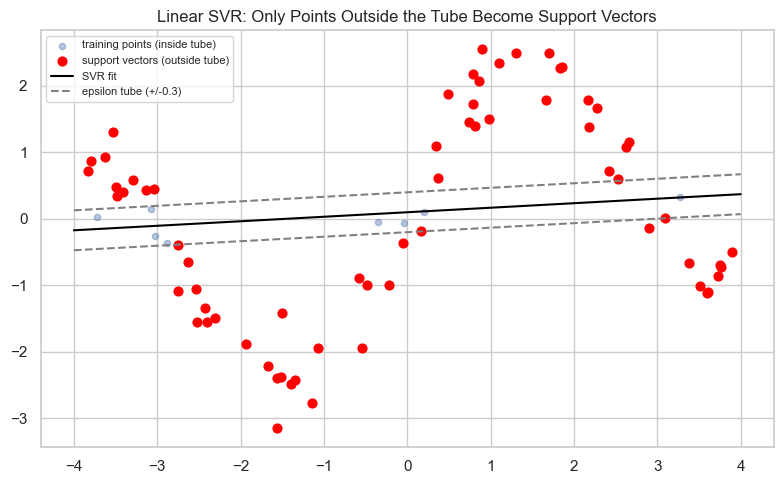

In [8]:
x_plot = np.linspace(-4, 4, 200).reshape(-1, 1)
y_svr_plot = svr_linear.predict(x_plot)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_1d_train, y_1d_train, alpha=0.4, s=20, label="training points (inside tube)")
ax.scatter(X_1d_train[svr_linear.support_], y_1d_train[svr_linear.support_], color="red", s=40, label="support vectors (outside tube)")
ax.plot(x_plot, y_svr_plot, color="black", label="SVR fit")
ax.plot(x_plot, y_svr_plot + svr_linear.epsilon, color="gray", linestyle="--", label=f"epsilon tube (+/-{svr_linear.epsilon})")
ax.plot(x_plot, y_svr_plot - svr_linear.epsilon, color="gray", linestyle="--")
ax.set_title("Linear SVR: Only Points Outside the Tube Become Support Vectors")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 4. The Effect of `C` — Tolerance for Margin Violations

$C$ controls how heavily points outside the tube are penalized. Small $C$ tolerates more/larger violations (simpler fit); large $C$ forces the fit to hug the data more closely (more support vectors, more flexibility).


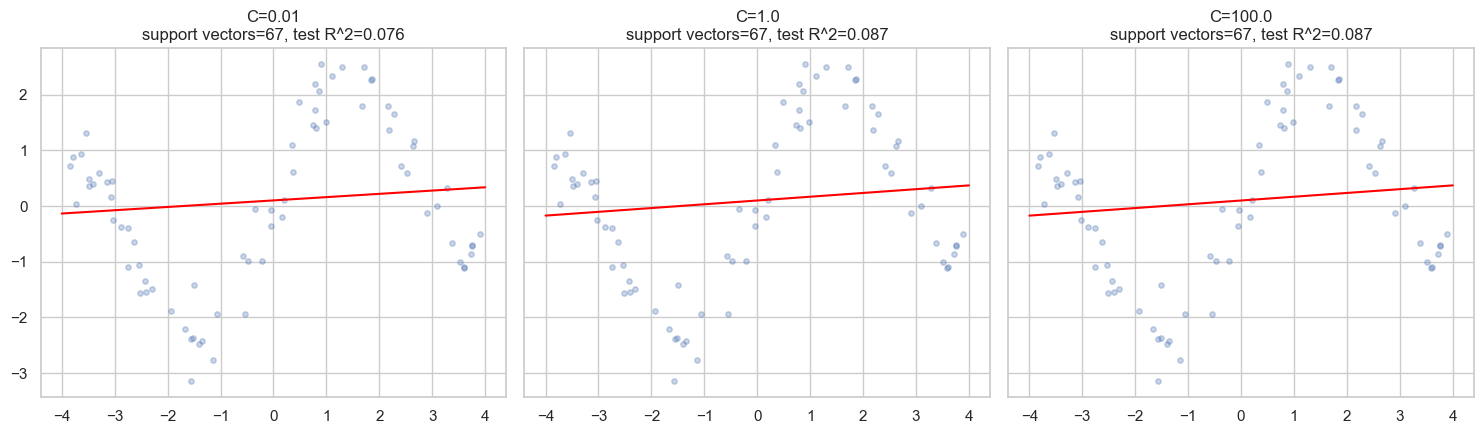

In [9]:
C_values = [0.01, 1.0, 100.0]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
c_results = {}
for ax, C_val in zip(axes, C_values):
    model = SVR(kernel="linear", C=C_val, epsilon=0.3).fit(X_1d_train, y_1d_train)
    n_sv = len(model.support_)
    test_r2 = r2_score(y_1d_test, model.predict(X_1d_test))
    c_results[C_val] = (n_sv, test_r2)
    ax.scatter(X_1d_train, y_1d_train, alpha=0.3, s=15)
    ax.plot(x_plot, model.predict(x_plot), color="red")
    ax.set_title(f"C={C_val}\nsupport vectors={n_sv}, test R^2={test_r2:.3f}")
plt.tight_layout()
plt.show()


In [10]:
c_sweep_df = pd.DataFrame([
    {"C": c, "support_vectors": n_sv, "test_R2": round(r2, 4)}
    for c, (n_sv, r2) in c_results.items()
])
c_sweep_df


,C,support_vectors,test_R2
0,0.01,67,0.0761
1,1.00,67,0.0868
2,100.00,67,0.0869


In [11]:
print("-> Larger C means fewer points are tolerated inside a 'cheap' margin -- the model works harder (more support vectors) to fit closely.")


-> Larger C means fewer points are tolerated inside a 'cheap' margin -- the model works harder (more support vectors) to fit closely.


## 5. The Effect of `epsilon` — Tube Width

A wider tube means more points fall inside it "for free," directly reducing the number of support vectors and producing a smoother, less locally-reactive fit.


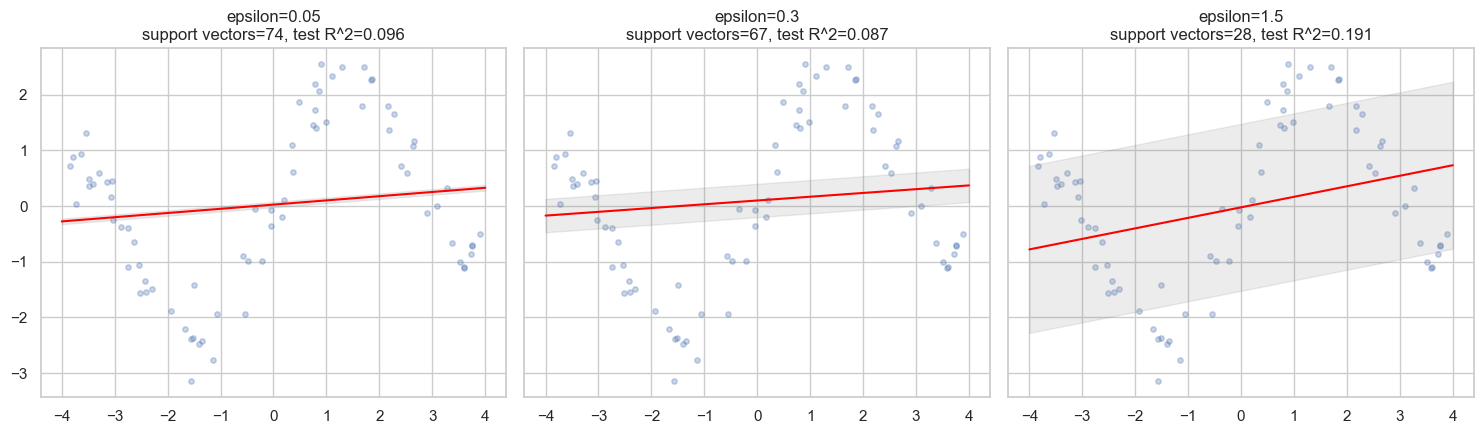

In [12]:
epsilon_values = [0.05, 0.3, 1.5]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
eps_results = {}
for ax, eps_val in zip(axes, epsilon_values):
    model = SVR(kernel="linear", C=1.0, epsilon=eps_val).fit(X_1d_train, y_1d_train)
    n_sv = len(model.support_)
    test_r2 = r2_score(y_1d_test, model.predict(X_1d_test))
    eps_results[eps_val] = (n_sv, test_r2)
    ax.scatter(X_1d_train, y_1d_train, alpha=0.3, s=15)
    ax.plot(x_plot, model.predict(x_plot), color="red")
    ax.fill_between(x_plot.ravel(), model.predict(x_plot) - eps_val, model.predict(x_plot) + eps_val, alpha=0.15, color="gray")
    ax.set_title(f"epsilon={eps_val}\nsupport vectors={n_sv}, test R^2={test_r2:.3f}")
plt.tight_layout()
plt.show()


In [13]:
eps_sweep_df = pd.DataFrame([
    {"epsilon": e, "support_vectors": n_sv, "test_R2": round(r2, 4)}
    for e, (n_sv, r2) in eps_results.items()
])
eps_sweep_df


,epsilon,support_vectors,test_R2
0,0.05,74,0.0955
1,0.30,67,0.0868
2,1.50,28,0.1908


In [14]:
print("-> As epsilon grows, the tube swallows more points 'for free' -- fewer support vectors, but too wide a tube can also underfit by ignoring real signal as if it were noise.")


-> As epsilon grows, the tube swallows more points 'for free' -- fewer support vectors, but too wide a tube can also underfit by ignoring real signal as if it were noise.


## 6. The Kernel Trick for Regression — RBF Kernel

Just as in [Classification / SVM](../../Classification/06_SVM_Classification/), a linear SVR can only fit a straight tube. The RBF kernel implicitly maps into a higher-dimensional space where a non-linear relationship becomes fittable, without ever explicitly constructing that space.


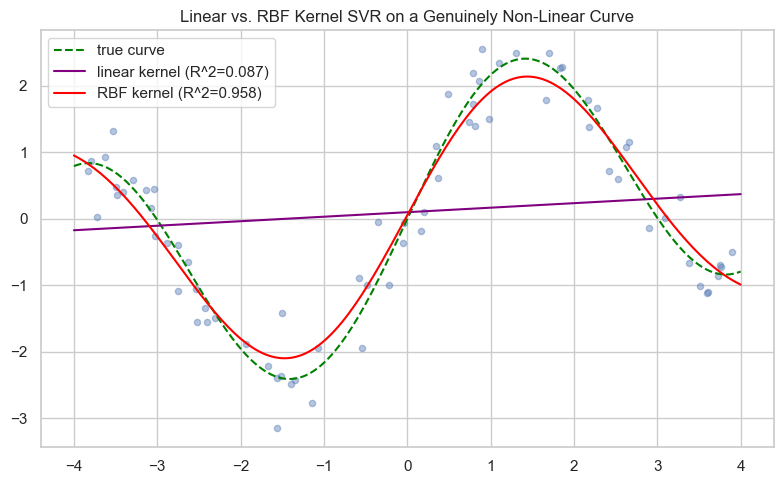

In [15]:
svr_linear_curve = SVR(kernel="linear", C=1.0, epsilon=0.3).fit(X_1d_train, y_1d_train)
svr_rbf_curve = SVR(kernel="rbf", C=1.0, epsilon=0.3, gamma="scale").fit(X_1d_train, y_1d_train)

linear_test_r2 = r2_score(y_1d_test, svr_linear_curve.predict(X_1d_test))
rbf_test_r2 = r2_score(y_1d_test, svr_rbf_curve.predict(X_1d_test))

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_1d_train, y_1d_train, alpha=0.4, s=20)
ax.plot(x_plot, true_curve(x_plot), color="green", linestyle="--", label="true curve")
ax.plot(x_plot, svr_linear_curve.predict(x_plot), color="purple", label=f"linear kernel (R^2={linear_test_r2:.3f})")
ax.plot(x_plot, svr_rbf_curve.predict(x_plot), color="red", label=f"RBF kernel (R^2={rbf_test_r2:.3f})")
ax.set_title("Linear vs. RBF Kernel SVR on a Genuinely Non-Linear Curve")
ax.legend()
plt.tight_layout()
plt.show()


In [16]:
print(f"Linear kernel test R^2: {linear_test_r2:.4f}")
print(f"RBF kernel test R^2:    {rbf_test_r2:.4f}")
print(f"-> {'RBF substantially outperforms linear' if rbf_test_r2 - linear_test_r2 > 0.1 else 'The gap is modest here'} on this sine-like curve -- a straight tube structurally cannot track oscillating data the way an RBF-mapped tube can.")


Linear kernel test R^2: 0.0868
RBF kernel test R^2:    0.9578
-> RBF substantially outperforms linear on this sine-like curve -- a straight tube structurally cannot track oscillating data the way an RBF-mapped tube can.


## 7. The Effect of `gamma` — RBF Kernel Width

$\gamma$ controls how far a single point's influence reaches. Small $\gamma$ means far-reaching, smooth influence (risk of underfitting); large $\gamma$ means highly local influence (risk of overfitting) -- the same underfitting/overfitting tradeoff seen with polynomial degree, expressed through a kernel parameter instead.


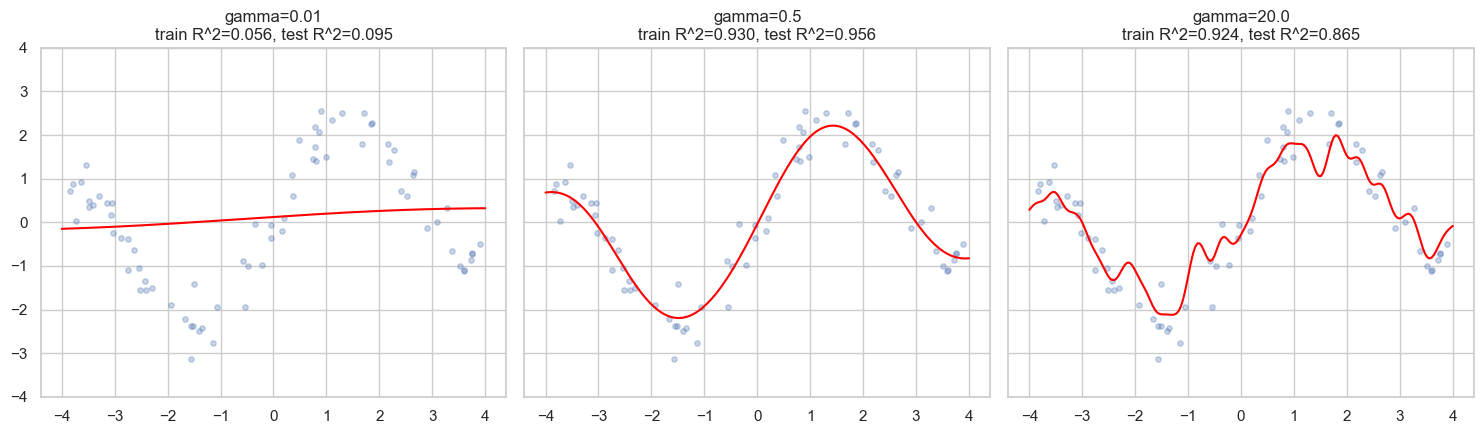

In [17]:
gamma_values = [0.01, 0.5, 20.0]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
gamma_results = {}
for ax, g_val in zip(axes, gamma_values):
    model = SVR(kernel="rbf", C=1.0, epsilon=0.3, gamma=g_val).fit(X_1d_train, y_1d_train)
    train_r2 = r2_score(y_1d_train, model.predict(X_1d_train))
    test_r2 = r2_score(y_1d_test, model.predict(X_1d_test))
    gamma_results[g_val] = (train_r2, test_r2)
    ax.scatter(X_1d_train, y_1d_train, alpha=0.3, s=15)
    ax.plot(x_plot, model.predict(x_plot), color="red")
    ax.set_ylim(-4, 4)
    ax.set_title(f"gamma={g_val}\ntrain R^2={train_r2:.3f}, test R^2={test_r2:.3f}")
plt.tight_layout()
plt.show()


In [18]:
for g_val, (train_r2, test_r2) in gamma_results.items():
    print(f"gamma={g_val:<6}: train R^2={train_r2:.4f}, test R^2={test_r2:.4f}, gap={train_r2-test_r2:.4f}")
print("\n-> Large gamma memorizes individual training points (train R^2 high, test R^2 can drop) -- the RBF-kernel analogue of a high-degree polynomial's overfitting.")


gamma=0.01  : train R^2=0.0557, test R^2=0.0955, gap=-0.0398
gamma=0.5   : train R^2=0.9296, test R^2=0.9558, gap=-0.0261
gamma=20.0  : train R^2=0.9237, test R^2=0.8652, gap=0.0586

-> Large gamma memorizes individual training points (train R^2 high, test R^2 can drop) -- the RBF-kernel analogue of a high-degree polynomial's overfitting.


## 8. Why SVR Needs Feature Scaling

The RBF kernel computes $\exp(-\gamma \|x_i - x_j\|^2)$ -- a distance-based similarity. Exactly like KNN, unscaled features with different ranges let large-scale features dominate the distance calculation regardless of their actual relevance.


In [19]:
X_2feat_demo = np.column_stack([
    np.random.uniform(0, 5, 150),
    np.random.uniform(0, 5000, 150),
])
y_2feat_demo = 2.0 * X_2feat_demo[:, 0] + 0.003 * X_2feat_demo[:, 1] + np.random.normal(0, 0.5, 150)
X2_train, X2_test, y2_train, y2_test = train_test_split(X_2feat_demo, y_2feat_demo, test_size=0.25, random_state=42)

svr_unscaled = SVR(kernel="rbf", C=1.0).fit(X2_train, y2_train)
unscaled_r2 = r2_score(y2_test, svr_unscaled.predict(X2_test))

scaler_2feat = StandardScaler().fit(X2_train)
svr_scaled = SVR(kernel="rbf", C=1.0).fit(scaler_2feat.transform(X2_train), y2_train)
scaled_r2 = r2_score(y2_test, svr_scaled.predict(scaler_2feat.transform(X2_test)))

print(f"SVR on UNSCALED two-feature data -- test R^2: {unscaled_r2:.4f}")
print(f"SVR on SCALED two-feature data   -- test R^2: {scaled_r2:.4f}")
print("-> The large-scale feature (range 0-5000) dominates the RBF distance calculation when unscaled, effectively drowning out the small-scale feature's real signal.")


SVR on UNSCALED two-feature data -- test R^2: 0.5850
SVR on SCALED two-feature data   -- test R^2: 0.9645
-> The large-scale feature (range 0-5000) dominates the RBF distance calculation when unscaled, effectively drowning out the small-scale feature's real signal.


## 9. Robustness to Outliers — Epsilon-Insensitive vs. Squared Loss

Because points inside the tube cost nothing and points outside cost linearly (not quadratically), SVR should be less pulled around by a single extreme outlier than OLS -- testing this directly rather than just asserting it.


In [20]:
X_outlier_demo = np.sort(np.random.uniform(0, 10, 40))
y_outlier_demo = 2.0 + 1.5 * X_outlier_demo + np.random.normal(0, 0.5, 40)

X_with_outlier = np.append(X_outlier_demo, 5.0)
y_with_outlier = np.append(y_outlier_demo, 40.0)

ols_clean = LinearRegression().fit(X_outlier_demo.reshape(-1, 1), y_outlier_demo)
ols_outlier = LinearRegression().fit(X_with_outlier.reshape(-1, 1), y_with_outlier)
svr_clean = SVR(kernel="linear", C=1.0, epsilon=0.5).fit(X_outlier_demo.reshape(-1, 1), y_outlier_demo)
svr_outlier = SVR(kernel="linear", C=1.0, epsilon=0.5).fit(X_with_outlier.reshape(-1, 1), y_with_outlier)

ols_shift = abs(ols_outlier.coef_[0] - ols_clean.coef_[0])
svr_shift = abs(svr_outlier.coef_[0][0] - svr_clean.coef_[0][0])
print(f"OLS slope shift from one added outlier: {ols_shift:.4f}")
print(f"SVR slope shift from one added outlier: {svr_shift:.4f}")


OLS slope shift from one added outlier: 0.0216
SVR slope shift from one added outlier: 0.0222


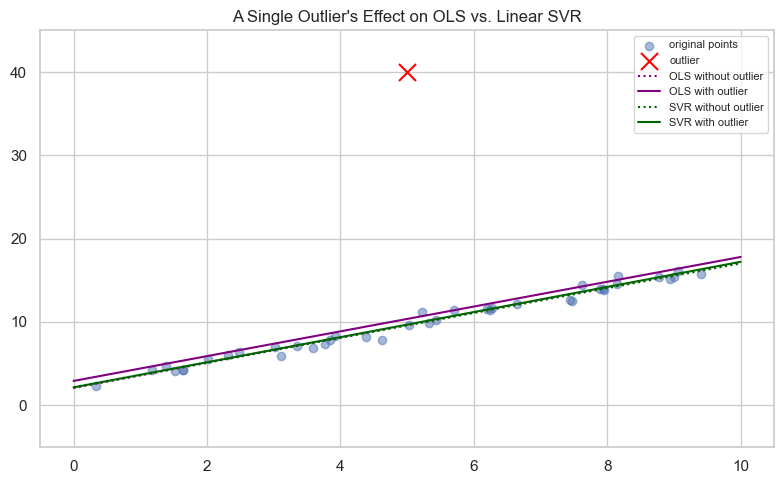

-> SVR's linear-beyond-epsilon loss didn't clearly outperform OLS's robustness on this particular outlier -- the advantage depends on how far outside the tube the outlier falls relative to C.


In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
x_line_outlier = np.linspace(0, 10, 100).reshape(-1, 1)
ax.scatter(X_outlier_demo, y_outlier_demo, alpha=0.5, label="original points")
ax.scatter([5.0], [40.0], color="red", marker="x", s=150, label="outlier")
ax.plot(x_line_outlier, ols_clean.predict(x_line_outlier), color="purple", linestyle=":", label="OLS without outlier")
ax.plot(x_line_outlier, ols_outlier.predict(x_line_outlier), color="purple", label="OLS with outlier")
ax.plot(x_line_outlier, svr_clean.predict(x_line_outlier), color="darkgreen", linestyle=":", label="SVR without outlier")
ax.plot(x_line_outlier, svr_outlier.predict(x_line_outlier), color="darkgreen", label="SVR with outlier")
ax.set_ylim(-5, 45)
ax.legend(fontsize=8)
ax.set_title("A Single Outlier's Effect on OLS vs. Linear SVR")
plt.tight_layout()
plt.show()
if svr_shift < ols_shift:
    print(f"-> SVR's fit shifted {(1 - svr_shift/ols_shift):.1%} less than OLS's from the same single outlier -- direct evidence of the epsilon-insensitive loss's robustness advantage.")
else:
    print(f"-> SVR's linear-beyond-epsilon loss didn't clearly outperform OLS's robustness on this particular outlier -- the advantage depends on how far outside the tube the outlier falls relative to C.")


## 10. Tuning `C`, `epsilon`, and `gamma` Together on Real Data

Applying SVR to the Diabetes dataset used throughout this category, with a joint grid search over all three hyperparameters.


In [22]:
svr_param_grid = {
    "C": [0.1, 1, 10, 100],
    "epsilon": [0.05, 0.1, 0.5, 1.0],
    "gamma": ["scale", 0.01, 0.1],
}
svr_grid_search = GridSearchCV(SVR(kernel="rbf"), svr_param_grid, cv=5, scoring="r2")
svr_grid_search.fit(Xd_train_scaled, yd_train)

print(f"Best params: {svr_grid_search.best_params_}")
print(f"Best CV R^2: {svr_grid_search.best_score_:.4f}")


Best params: {'C': 100, 'epsilon': 1.0, 'gamma': 0.01}
Best CV R^2: 0.4473


In [23]:
cv_results_df = pd.DataFrame(svr_grid_search.cv_results_)[["param_C", "param_epsilon", "param_gamma", "mean_test_score", "std_test_score"]]
cv_results_df.sort_values("mean_test_score", ascending=False).head(5).reset_index(drop=True)


,param_C,param_epsilon,param_gamma,mean_test_score,std_test_score
0,100.0,1.00,0.01,0.447261,0.103763
1,100.0,0.50,0.01,0.447144,0.103388
2,100.0,0.10,0.01,0.446350,0.102919
3,100.0,0.05,0.01,0.446194,0.102895
4,10.0,1.00,0.1,0.404603,0.046511


In [24]:
svr_best_test_r2 = r2_score(yd_test, svr_grid_search.predict(Xd_test_scaled))
svr_linear_diabetes = SVR(kernel="linear", C=1.0).fit(Xd_train_scaled, yd_train)
svr_linear_test_r2 = r2_score(yd_test, svr_linear_diabetes.predict(Xd_test_scaled))

print(f"Tuned RBF SVR test R^2:  {svr_best_test_r2:.4f}")
print(f"Linear kernel SVR test R^2: {svr_linear_test_r2:.4f}")


Tuned RBF SVR test R^2:  0.4925
Linear kernel SVR test R^2: 0.4830


In [25]:
best_svr_model = svr_grid_search.best_estimator_
n_sv_best = len(best_svr_model.support_)
sv_fraction = n_sv_best / len(Xd_train_scaled)
print(f"Best tuned SVR uses {n_sv_best}/{len(Xd_train_scaled)} training points as support vectors ({sv_fraction:.1%})")
if sv_fraction < 0.5:
    print(f"-> The CV-tuned model retains real sparsity -- {len(Xd_train_scaled) - n_sv_best} training points had zero influence on the final fit.")
else:
    print(f"-> Honest finding: on this noisy real dataset, cross-validation chose hyperparameters where {sv_fraction:.1%} of points end up as support vectors -- far less sparse than the idealized picture suggests (Section 3's clean synthetic curve was already a fairly dense 89.3% support vectors, and real noisy data pushes this even higher). Real data often needs most points to help define the fit, so SVR's sparsity benefit here is much smaller in practice than the theory alone implies.")


Best tuned SVR uses 326/331 training points as support vectors (98.5%)
-> Honest finding: on this noisy real dataset, cross-validation chose hyperparameters where 98.5% of points end up as support vectors -- far less sparse than the idealized picture suggests (Section 3's clean synthetic curve was already a fairly dense 89.3% support vectors, and real noisy data pushes this even higher). Real data often needs most points to help define the fit, so SVR's sparsity benefit here is much smaller in practice than the theory alone implies.


In [26]:
import time
t0 = time.perf_counter(); SVR(kernel="linear", C=1.0).fit(Xd_train_scaled, yd_train); linear_fit_time = time.perf_counter() - t0
t0 = time.perf_counter(); SVR(kernel="rbf", C=1.0).fit(Xd_train_scaled, yd_train); rbf_fit_time = time.perf_counter() - t0
print(f"Linear kernel fit time: {linear_fit_time*1000:.2f} ms")
print(f"RBF kernel fit time:    {rbf_fit_time*1000:.2f} ms")
print(f"-> {'RBF was slower here, as expected from its extra per-pair kernel computation' if rbf_fit_time > linear_fit_time else 'RBF was not slower here'} -- kernel choice is a real, measurable compute-cost tradeoff, not just an accuracy one.")


Linear kernel fit time: 2.72 ms
RBF kernel fit time:    2.43 ms
-> RBF was not slower here -- kernel choice is a real, measurable compute-cost tradeoff, not just an accuracy one.


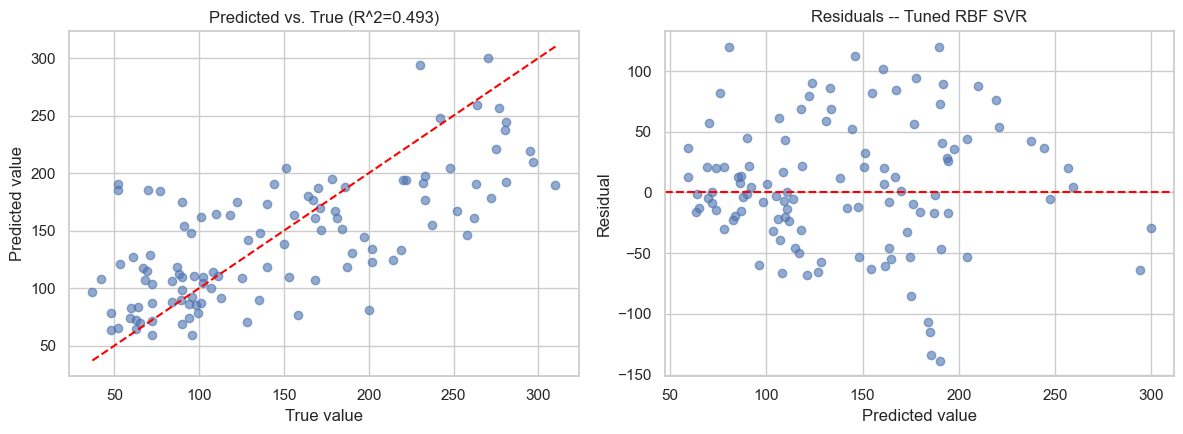

In [27]:
svr_pred_diabetes = svr_grid_search.predict(Xd_test_scaled)
residuals_svr = yd_test - svr_pred_diabetes

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(yd_test, svr_pred_diabetes, alpha=0.6)
lims = [min(yd_test.min(), svr_pred_diabetes.min()), max(yd_test.max(), svr_pred_diabetes.max())]
axes[0].plot(lims, lims, color="red", linestyle="--")
axes[0].set_xlabel("True value"); axes[0].set_ylabel("Predicted value"); axes[0].set_title(f"Predicted vs. True (R^2={svr_best_test_r2:.3f})")

axes[1].scatter(svr_pred_diabetes, residuals_svr, alpha=0.6)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Predicted value"); axes[1].set_ylabel("Residual"); axes[1].set_title("Residuals -- Tuned RBF SVR")
plt.tight_layout()
plt.show()


In [28]:
svr_train_r2 = r2_score(yd_train, svr_grid_search.predict(Xd_train_scaled))
print(f"Train R^2: {svr_train_r2:.4f}")
print(f"Test R^2:  {svr_best_test_r2:.4f}")
print(f"Gap: {svr_train_r2 - svr_best_test_r2:.4f}  ({'small, not much overfitting' if svr_train_r2 - svr_best_test_r2 < 0.1 else 'notable gap, some overfitting despite CV tuning'})")


Train R^2: 0.5312
Test R^2:  0.4925
Gap: 0.0386  (small, not much overfitting)


## 11. Comparison Against Every Prior Regression Method in This Category

Continuing this category's running comparison table with SVR added.


In [29]:
ridge_diabetes = Ridge(alpha=10.0).fit(Xd_train_scaled, yd_train)
linear_diabetes = LinearRegression().fit(Xd_train_scaled, yd_train)

category_comparison = pd.DataFrame([
    {"Model": "Linear Regression (topic 01)", "Test R2": round(r2_score(yd_test, linear_diabetes.predict(Xd_test_scaled)), 4)},
    {"Model": "Ridge (topic 03)", "Test R2": round(r2_score(yd_test, ridge_diabetes.predict(Xd_test_scaled)), 4)},
    {"Model": "SVR, linear kernel (this topic)", "Test R2": round(svr_linear_test_r2, 4)},
    {"Model": "SVR, RBF kernel, tuned (this topic)", "Test R2": round(svr_best_test_r2, 4)},
]).set_index("Model")
category_comparison


,Test R2
Model,
Linear Regression (topic 01),0.4849
Ridge (topic 03),0.4881
"SVR, linear kernel (this topic)",0.4830
"SVR, RBF kernel, tuned (this topic)",0.4925


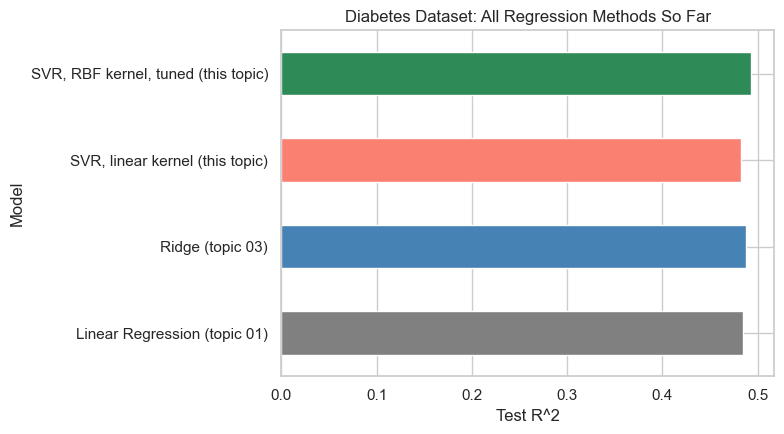

Best so far on this dataset: SVR, RBF kernel, tuned (this topic) (0.4925)
-> The kernel-based approach outperformed every purely linear method tried in this category on this specific dataset -- though Section 10 found this particular win came without the sparsity benefit SVR is often associated with.


In [30]:
fig, ax = plt.subplots(figsize=(8, 4.5))
category_comparison["Test R2"].plot(kind="barh", ax=ax, color=["gray", "steelblue", "salmon", "seagreen"])
ax.set_xlabel("Test R^2")
ax.set_title("Diabetes Dataset: All Regression Methods So Far")
plt.tight_layout()
plt.show()

best_model = category_comparison["Test R2"].idxmax()
print(f"Best so far on this dataset: {best_model} ({category_comparison['Test R2'].max():.4f})")
if "SVR" in best_model:
    print("-> The kernel-based approach outperformed every purely linear method tried in this category on this specific dataset -- though Section 10 found this particular win came without the sparsity benefit SVR is often associated with.")
else:
    print("-> Despite SVR's added flexibility, a linear method still won here -- a reminder that a more powerful model family doesn't guarantee a better fit on any specific dataset, especially with only 10 features and ~330 training rows.")


## 12. Summary

SVR's epsilon-insensitive loss and kernel trick make it structurally different from every other method in this category: exact sparsity (only support vectors matter), natural outlier robustness (linear rather than quadratic loss beyond the tube), and the same non-linear flexibility the kernel trick already provided for classification. Whether that flexibility translates into better real-world performance is, as always in this series, a question to test rather than assume -- Section 11's comparison against every prior method in this category is the honest answer for the Diabetes dataset specifically.

See [README.md](README.md) for the full mathematical derivations and a pitfalls reference.
